In [3]:
using OralQual
using LinearAlgebra
using CairoMakie
using Distributions
using Random
using ColorSchemes
using MAT
using SparseArrays
using ControlSystems
include("PrettyPlots.jl")

@inline colmean(V::AbstractMatrix) = vec(mean(V, dims=2))

function _samplecov(V::AbstractMatrix)
    # computes sample covariance (column-wise)
    J = size(V, 2)
    μ = colmean(V)
    X = V .- μ
    return (X * X') / (J-1)
end

_samplecov (generic function with 1 method)

# **Linear Bayesian Smoothing Problem**

In this demo, we show how our algorithm can be applied to solve linear Bayesian smoothing problems, i.e., to infer the initial condition of a linear dynamical system from noisy observations of the system output. We consider a linear dynamical system with linear output:

$$
\begin{align*}
\dot{\mathbf{x}}(t) &= \mathbf{A}\mathbf{x}(t),\\
\boldsymbol{y}(t) &= \mathbf{F}\mathbf{x}(t),
\end{align*}
$$

where $\mathbf{x}(t)\in\mathbb{R}^d$, $\mathbf{A}\in\mathbb{R}^{d\times d}$, $\mathbf{F}\in\mathbb{R}^{d_{\text{out}}\times d}$, and the initial state $\mathbf{x}(0) = \mathbf{v}$ is unknown. We take noisy measurements, $\mathbf{y}_k$, of the output $\boldsymbol{y}$ at times $t_1 < t_2 < \cdots <t_m$ according to the following measurement model:

$$
\mathbf{y}_k \equiv \mathbf{Fx}(t_k) + \boldsymbol{\eta}_k = \mathbf{F}e^{\mathbf{A}t_k}\mathbf{v} + \boldsymbol{\eta}_k,
$$

where $\boldsymbol{\eta}_k\sim\mathcal{N}(\boldsymbol{0},\mathbf{\Gamma}_\eta)$, with $\mathbf{\Gamma}_\eta\in\mathbb{R}^{d_{\text{out}}\times d_{\text{out}}}$. This defines a linear measurement model of the form $\mathbf{y} = \mathbf{Hv} + \boldsymbol{\varepsilon}$, where:

$$
\mathbf{y} = 
\begin{bmatrix}
\mathbf{y}_1 \\ \vdots \\ \mathbf{y}_m
\end{bmatrix}\in \mathbb{R}^n, \qquad
\mathbf{H} = 
\begin{bmatrix}
\mathbf{F}e^{\mathbf{A}t_1} \\ \vdots \\ \mathbf{F}e^{\mathbf{A}t_m}
\end{bmatrix} \in\mathbb{R}^{n\times d}, \qquad
\mathbf{\Gamma} = 
\begin{bmatrix}
\mathbf{\Gamma}_\eta & & \\
& \ddots & \\
&  &  \mathbf{\Gamma}_\eta
\end{bmatrix}\in\mathbb{R}^{n\times n},
$$

with $n = m\cdot d_\text{out}$ and $\boldsymbol{\varepsilon}\sim\mathcal{N}(\boldsymbol{0},\mathbf{\Gamma})$. We endow $\mathbf{v}$ with a centered Gaussian prior $\mathbf{v}\sim\mathcal{N}(\boldsymbol{0},\mathbf{\Gamma}_\text{pr})$. Then, the posterior is Gaussian $\mathcal{N}(\boldsymbol{\mu}_\text{pos}, \boldsymbol{\Gamma}_\text{pos})$, with:

$$
\boldsymbol{\Gamma}_\text{pos} = \left(\mathbf{H}^\top\mathbf{\Gamma}^{-1}\mathbf{H} + \mathbf{\Gamma}_\text{pr}^{-1}\right)^{-1}, \qquad \boldsymbol{\mu}_\text{pos} = \mathbf{\Gamma}_\text{pos}\mathbf{H}^\top\mathbf{\Gamma}^{-1}\mathbf{y}.
$$

For this example, we consider the heat equation on a one-dimensional rod with homogeneous Dirichlet boundary conditions. The state and output dimensions are $d=200$ and $d_\text{out} = 1$, respectively, with the output being the temperature measured at $2/3$ of the rod length.

## **Problem Setup**

In [5]:
path = "../data/heat-cont.mat"
n = 100 # number of measurements
Δt = 1e-3 # integrator time step
T_stop = 10.0 # integration end time
heat = heat_eq_params(n, Δt, T_stop, path)
d = heat.d

200

## **Data Generation**

In [7]:
Γ_pr = lyap(Matrix(heat.A), I(heat.d))
truth = rand(MvNormal(vec(zeros(1,d)),Symmetric(Γ_pr)))
sol_nonoise = solve_HE(heat, truth)
h, Δt = heat.h, heat.Δt
meas_idx = Int.(round.(heat.T_meas ./Δt))
y_nonoise = sol_nonoise[meas_idx]
σ = 0.08*maximum(abs.(y_nonoise))
γ = fill(σ^2, n)
Γ = γ .* I(n)
ε = rand(MvNormal(vec(zeros(1,n)),Γ))
y = y_nonoise + ε;

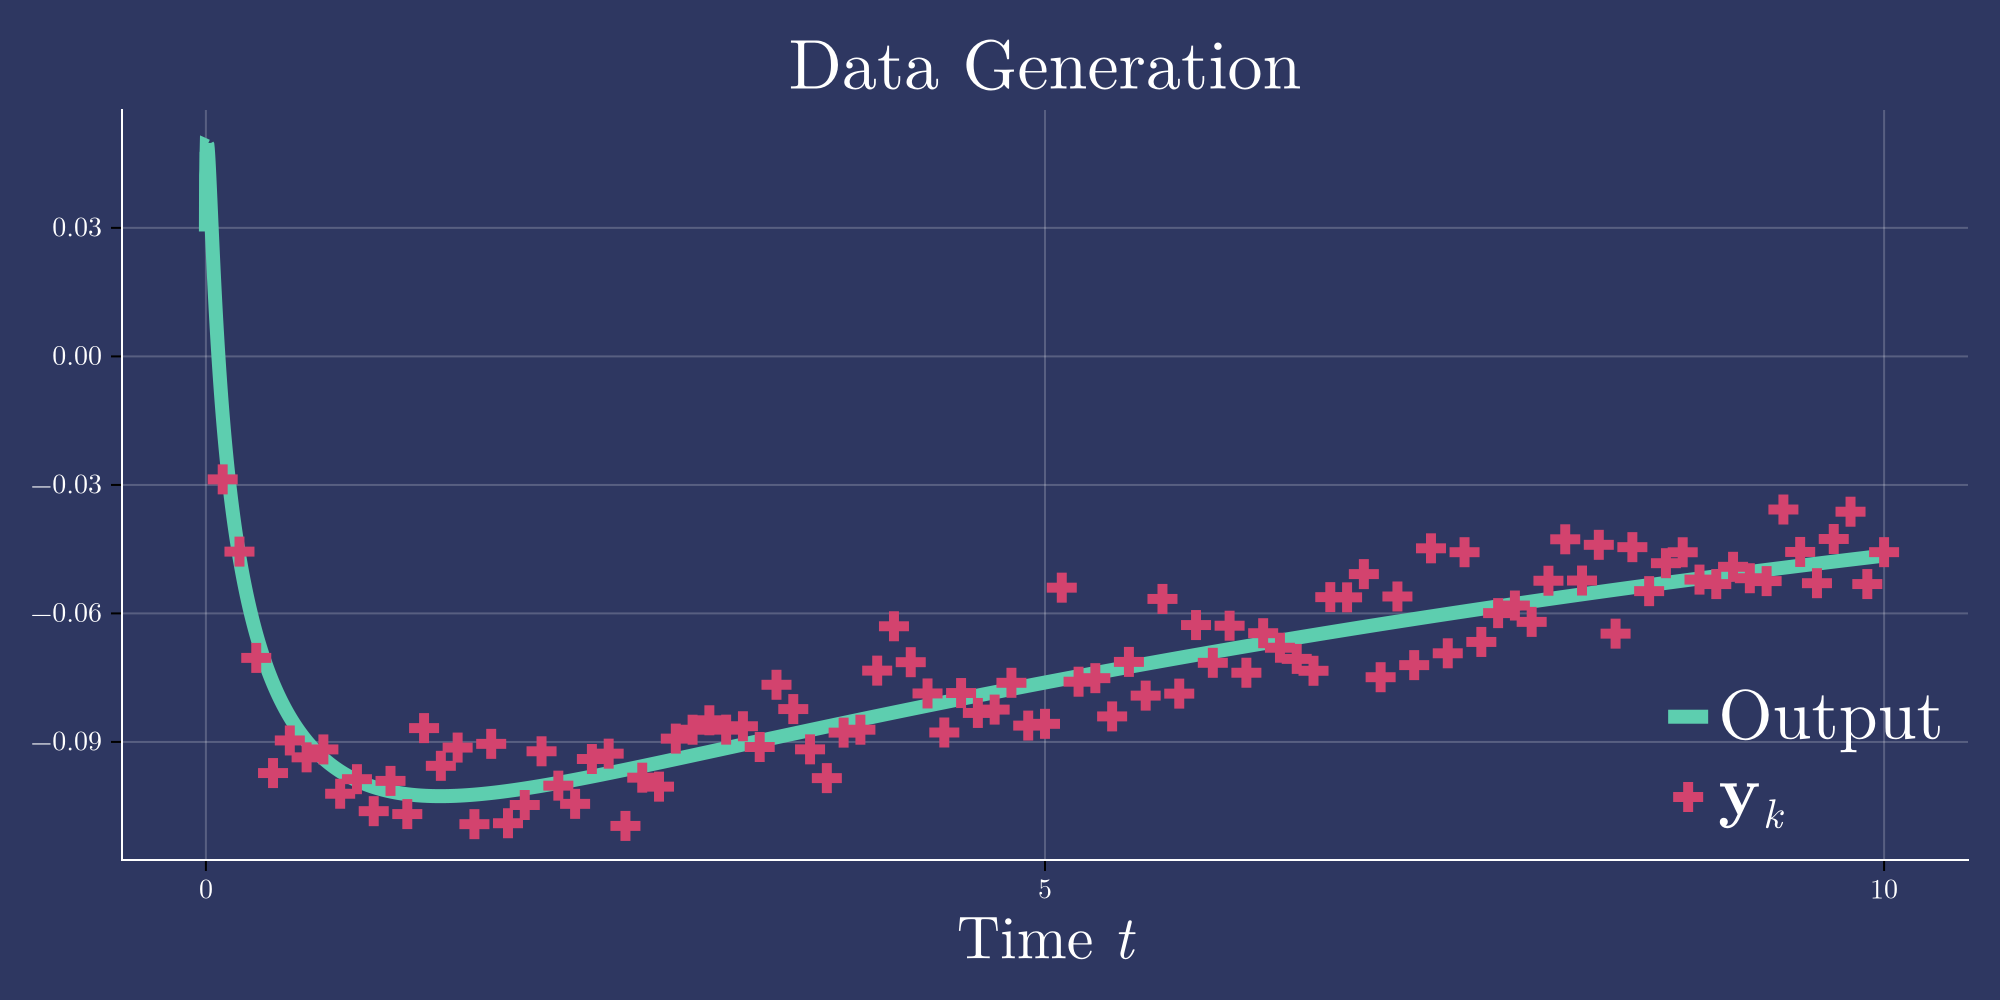

In [21]:
# Plot solution and data
colors = my_custom_dark_theme.palette.color[]
fig = themed_figure(; dark=true, size=(1000, 500)) do fig
    ax1 = Axis(fig[1, 1],
        title     = L"\text{Data Generation}",
        xlabel    = L"\text{Time }t",
        titlesize = 35,
        xlabelsize = 30
    )

    lines!(ax1, heat.TT, vec(sol_nonoise);
        linewidth = 7,
        color = colors[4],
        label = L"\text{Output}"
    )

    scatter!(ax1, heat.T_meas, y;
        color = colors[2],
        marker =:cross,
        markersize = 20,
        label = L"𝐲_k"
    )

    axislegend(ax1; position=:rb, framevisible=false, labelsize=35)
    fig
end

## **Exact posterior**
We compute the exact posterior mean and covariance as defined above:

In [23]:
H = heat.H
Fish = (H'/Γ)*H
Γ_pos = (Fish + Γ_pr\I)\I
μ_pos = (Γ_pos*H'/Γ)*y;

## **EKRMLE**
We solve the Bayesian inverse problem with prior $\mathcal{N}(\boldsymbol{0},\mathbf{\Gamma}_\text{pr})$ and the RLS operators.

In [24]:
Γ_RLS = Matrix{Float64}(I(n+d))
Γ_RLS[1:n, 1:n] .= Matrix{Float64}(Γ)
Γ_RLS[n+1:end, n+1:end] .= Matrix{Float64}(Γ_pr)
Γ_RLS = Symmetric(Γ_RLS)
y_RLS = vcat(Vector{Float64}(y), zeros(Float64, d))
H_RLS = vcat(heat.H, I(d))
H_RLS_s(::Nothing, v::AbstractVector) = H_RLS * v
J = 10000
V0 = rand(d, J)
ekrmleobj = EKRMLEObj(V0, y_RLS, Γ_RLS)
iters = 30
EKRMLE_run!(ekrmleobj, nothing, H_RLS_s, iters);

## **Covariance comparison**
We compare the ensemble covariance at the last iteration with the exact posterior covariance:

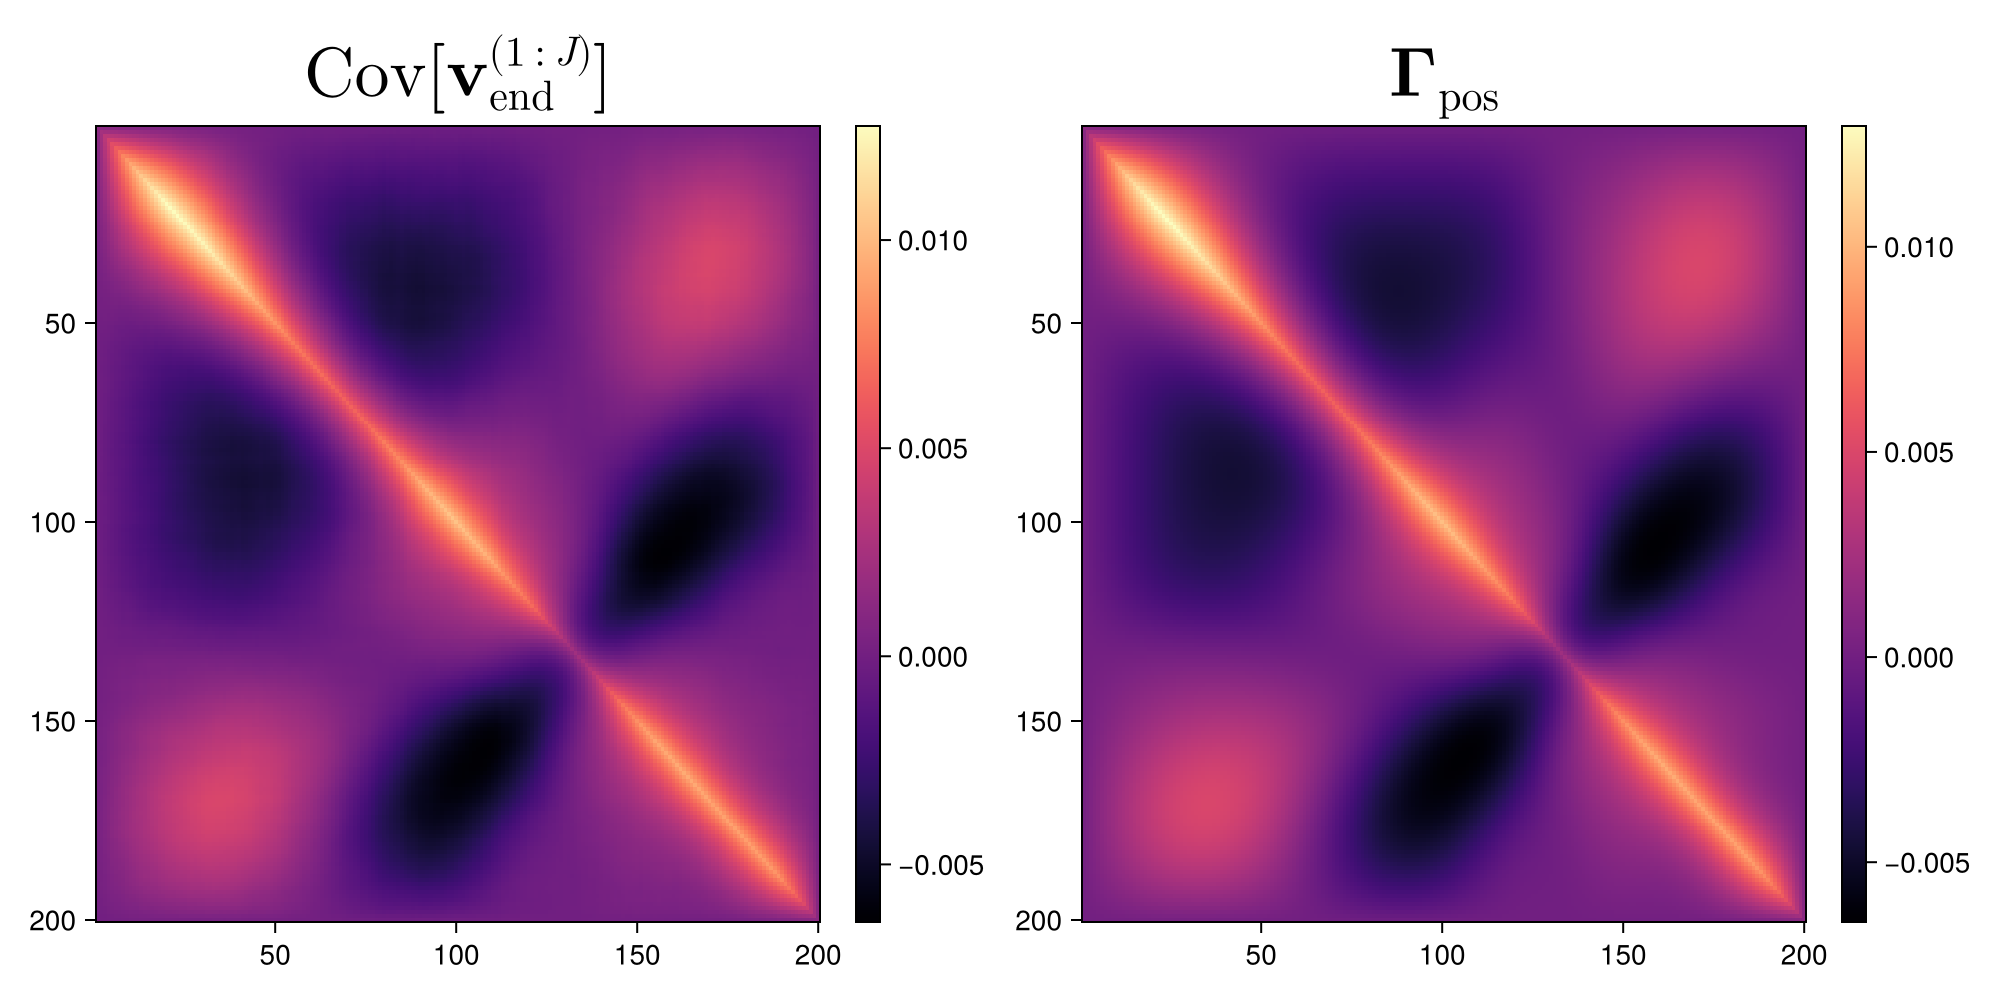

CairoMakie.Screen{IMAGE}


In [26]:
C = _samplecov(ekrmleobj.V[end])
## Covariance comparison
fig = Figure(size=(1000,500))
ax1 = Axis(fig[1, 1], title=L"\text{Cov}[\textbf{v}_\text{end}^{(1:J)}]", titlesize=35)
ax1.yreversed=true
ax2 = Axis(fig[1, 3], title = L"\textbf{Γ}_\text{pos}", titlesize=35)
ax2.yreversed=true
hm1 = heatmap!(ax1, C; colormap=:magma)
Colorbar(fig[1, 2], hm1)
hm2 = heatmap!(ax2, Γ_pos; colormap=:magma)
Colorbar(fig[1, 4], hm2)
display(fig)

## **Mean comparison**
We compare the ensemble mean at the last iteration with the exact posterior mean:

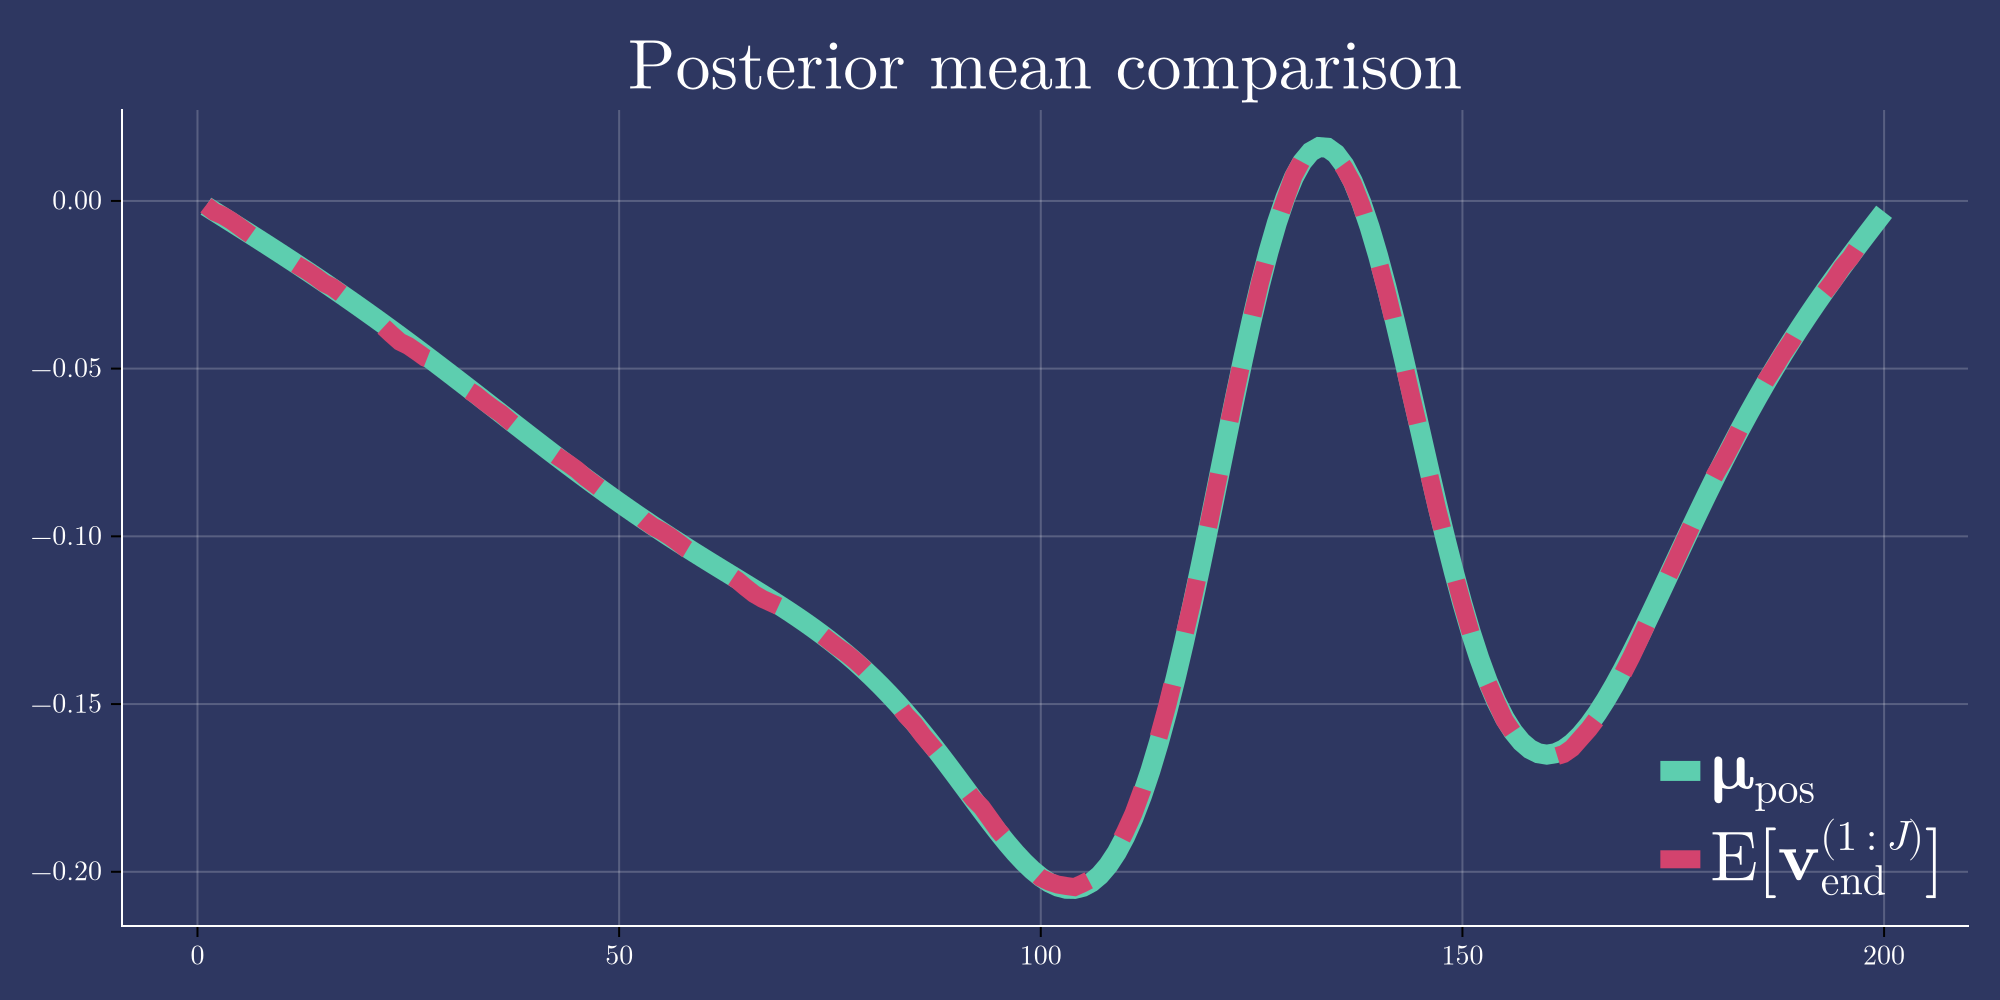

In [27]:
μ = colmean(ekrmleobj.V[end])

fig = themed_figure(; dark=true, size=(1000, 500)) do fig
    ax1 = Axis(fig[1, 1],
        title     = L"\text{Posterior mean comparison}",
        titlesize = 35
    )

    lines!(ax1, μ_pos;
        linewidth = 10,
        color = colors[4],
        label = L"𝛍_\text{pos}"
    )

    lines!(ax1, μ;
        color = colors[2],
        linewidth = 9,
        linestyle =:dash,
        label = L"\text{E}[\textbf{v}_\text{end}^{(1:J)}]"
    )

    axislegend(ax1; position=:rb, framevisible=false, labelsize=35)
    fig
end